# ***ASSIGNMENT-6***

## **Task 1 — Perform PCA on Mushroom Dataset**

**1️⃣ Task 1 — Perform PCA on Mushroom Dataset**

**What you must do**

1. Go to **Kaggle**
2. Download the dataset **mushrooms.csv**.

This dataset contains mushroom features used to classify **edible vs poisonous mushrooms**.

---

**Then write a Python program that:**

1. Load the dataset
2. Preprocess the data
3. Apply **Principal Component Analysis (PCA)**
4. Reduce the number of features
5. Show the PCA output

---
***Link of Dataset:*** https://www.kaggle.com/datasets/rumeysagnaydn/mushroomcsv

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

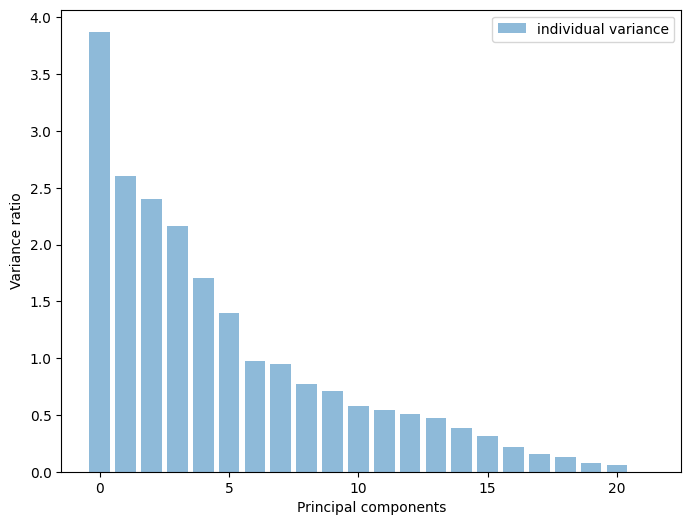

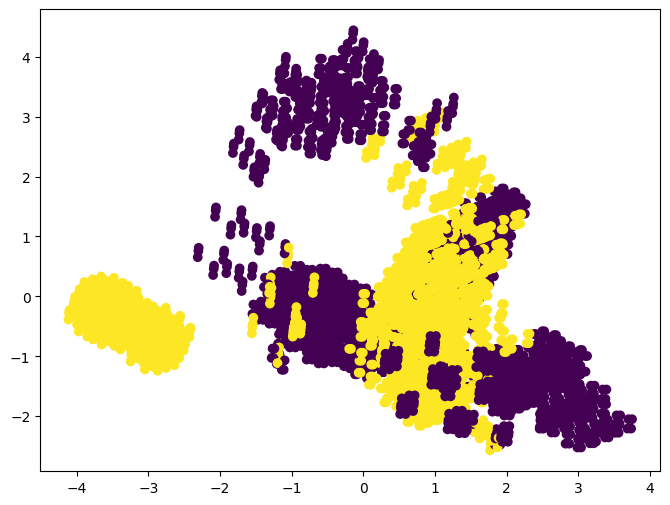

In [20]:
# PRINCIPAL COMPONENT ANALYSIS (PCA)

# Importing required libraries
import pandas as pd                 # Used for handling datasets (DataFrame)
from sklearn.decomposition import PCA   # PCA algorithm for dimensionality reduction
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Encoding and scaling
from sklearn.model_selection import train_test_split  # Used in ML for splitting data
import matplotlib.pyplot as plt     # Used for plotting graphs
import warnings                     # Used to hide unnecessary warnings

warnings.filterwarnings("ignore")   # Ignore warning messages


# ----------------------------------------------------------
# Step 1: Load the Mushroom Dataset
# ----------------------------------------------------------

df = pd.read_csv("mushrooms.csv")   # Reading the dataset using pandas

# Display first 5 rows of the dataset
print(df.head())

# Display number of rows and columns
print(df.shape)

# Display column names
print(df.columns)


# ----------------------------------------------------------
# Step 2: Encode categorical values into numeric values
# ----------------------------------------------------------
# Machine learning algorithms cannot work with string data,
# so we convert letters into numbers using LabelEncoder.

encoder = LabelEncoder()

# Apply encoding to all columns in the dataset
for col in df.columns:
    df[col] = encoder.fit_transform(df[col])


# ----------------------------------------------------------
# Step 3: Separate features and labels
# ----------------------------------------------------------
# X_features → Input features (independent variables)
# y_label → Target variable (class: edible or poisonous)

X_features = df.iloc[:,1:23]   # All columns except first column
y_label = df.iloc[:,0]         # First column (class)


# ----------------------------------------------------------
# Step 4: Standardize the feature values
# ----------------------------------------------------------
# PCA works better when data is scaled.
# StandardScaler converts data into mean=0 and variance=1.

scaler = StandardScaler()

X_features = scaler.fit_transform(X_features)


# ----------------------------------------------------------
# Step 5: Apply PCA
# ----------------------------------------------------------
# PCA reduces dimensionality while preserving most of the
# variance (information) in the dataset.

pca = PCA()

pca.fit_transform(X_features)

# Explained variance shows how much information each
# principal component contains.

pca_variance = pca.explained_variance_


# ----------------------------------------------------------
# Step 6: Plot variance of principal components
# ----------------------------------------------------------

plt.figure(figsize=(8,6))

# Bar chart showing variance explained by each component
plt.bar(range(22), pca_variance, alpha=0.5, align='center',
        label='individual variance')

plt.legend()
plt.ylabel('Variance ratio')
plt.xlabel('Principal components')

plt.show()


# ----------------------------------------------------------
# Step 7: Reduce dimensions using selected components
# ----------------------------------------------------------
# Here we reduce the dataset into 17 principal components.

pca2 = PCA(n_components=17)

pca2.fit(X_features)

# Transform original data into reduced dimensional space
x_3d = pca2.transform(X_features)


# ----------------------------------------------------------
# Step 8: Visualize PCA result
# ----------------------------------------------------------
# Scatter plot of selected principal components
# Points are colored according to mushroom class.

plt.figure(figsize=(8,6))

plt.scatter(x_3d[:,0], x_3d[:,5], c=df['class'])

plt.show()

**Conclusion:**

In this experiment, Principal Component Analysis was applied to the **Mushroom Dataset** to reduce the dimensionality of the dataset. Since the dataset contains many categorical features, they were first encoded into numerical values and standardized.

PCA was then used to transform the original 22 features into a smaller number of principal components while preserving most of the variance in the data. The variance plot helped visualize how much information each principal component contains. By selecting the top principal components, the dataset dimensionality was reduced without losing significant information.

Thus, PCA successfully simplified the dataset, reduced computational complexity, and helped visualize the important patterns present in the mushroom dataset.

## **2️⃣ Task 2 — Perform LDA on Iris Dataset**

Now you must apply **Linear Discriminant Analysis (LDA)** on the **Iris Dataset**.

   s_length  s_width  p_length  p_width  target species
0       5.1      3.5       1.4      0.2     0.0  setosa
1       4.9      3.0       1.4      0.2     0.0  setosa
2       4.7      3.2       1.3      0.2     0.0  setosa
3       4.6      3.1       1.5      0.2     0.0  setosa
4       5.0      3.6       1.4      0.2     0.0  setosa
0.9800000000000001
Prediction for [5, 3, 1, 0.4]: ['setosa']


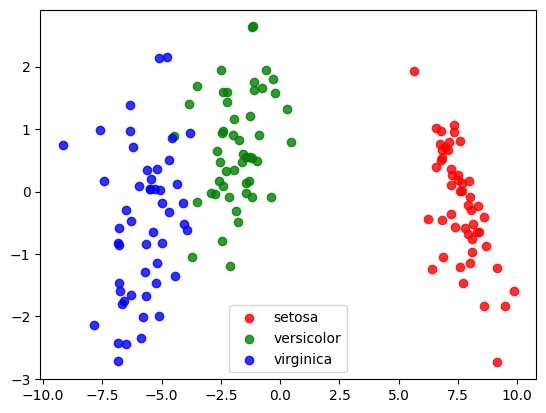

In [21]:
# Import required libraries

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn import datasets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ---------------------------------------------------------
# Step 1: Load the Iris Dataset
# ---------------------------------------------------------

# Load dataset from sklearn
iris = datasets.load_iris()

# Convert dataset into pandas DataFrame for easier handling
df = pd.DataFrame(
    data=np.c_[iris['data'], iris['target']],
    columns=iris['feature_names'] + ['target']
)

# Create a new column containing species names
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Rename columns for simplicity
df.columns = ['s_length','s_width','p_length','p_width','target','species']

# Display first five rows of dataset
print(df.head())


# ---------------------------------------------------------
# Step 2: Define predictor and response variables
# ---------------------------------------------------------

# X = Input features (independent variables)
X = df[['s_length','s_width','p_length','p_width']]

# y = Output class (species of flower)
y = df['species']


# ---------------------------------------------------------
# Step 3: Fit the LDA Model
# ---------------------------------------------------------

# Create LDA model
model = LinearDiscriminantAnalysis()

# Train the model using dataset
model.fit(X,y)


# ---------------------------------------------------------
# Step 4: Evaluate Model Accuracy
# ---------------------------------------------------------

# RepeatedStratifiedKFold performs repeated cross validation
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# Evaluate model using cross validation
scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)

# Print average accuracy
print(np.mean(scores))


# ---------------------------------------------------------
# Step 5: Predict Class for New Observation
# ---------------------------------------------------------

# Define new sample data
new = [5,3,1,0.4]

# Predict species for new sample
prediction = model.predict([new])

# Display prediction result
print(f"Prediction for {new}: {prediction}")


# ---------------------------------------------------------
# Step 6: Prepare Data for LDA Visualization
# ---------------------------------------------------------

# Use original iris dataset
X = iris.data
y = iris.target

# Create another LDA model for visualization
model_plot = LinearDiscriminantAnalysis()

# Transform data into LDA components
data_plot = model_plot.fit(X,y).transform(X)

# Store species names
target_names = iris.target_names


# ---------------------------------------------------------
# Step 7: Create LDA Scatter Plot
# ---------------------------------------------------------

plt.figure()

# Assign colors for different classes
colors = ['red','green','blue']

# Plot each class separately
for color, i, target_name in zip(colors, [0,1,2], target_names):
    plt.scatter(
        data_plot[y == i, 0],
        data_plot[y == i, 1],
        alpha=0.8,
        color=color,
        label=target_name
    )

# Add legend to identify classes
plt.legend(loc='best', shadow=False, scatterpoints=1)

# Display the plot
plt.show()

**Conclusion:**

In this experiment, Linear Discriminant Analysis was applied to the **Iris Dataset** to perform dimensionality reduction and classification. The dataset features such as sepal length, sepal width, petal length, and petal width were used to classify the iris flowers into three species: Setosa, Versicolor, and Virginica.

The LDA model was trained and evaluated using cross-validation, achieving a high classification accuracy of approximately **98%**. LDA transformed the original features into new components that maximize the separation between different classes. The scatter plot clearly showed distinct clusters for the three flower species.

Therefore, LDA effectively reduced the dimensionality of the dataset while improving class separability, making it a powerful method for supervised dimensionality reduction and classification tasks.